## **OceanOSSE:** Development Notebook

### **Description:**

Notebook to develop & evaluate basic pyinterp Regridders in OceanOSSE.

### **Created By:**

Ollie Tooth (oliver.tooth@noc.ac.uk)

In [1]:
import logging

import numpy as np
import pandas as pd
import pyinterp
import xarray as xr
from tqdm import tqdm
from xarray.indexes import NDPointIndex
from xoak import SklearnGeoBallTreeAdapter

from OceanOSSE.io.dataloader import NetCDFDataLoader

In [2]:
logger = logging.getLogger(__name__)

logging.basicConfig(
    format="⦿══⦿  OceanOSSE  ⦿══⦿  ║ %(levelname)10s ║ %(asctime)s ║ %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[logging.FileHandler("OceanOSSE.log"), logging.StreamHandler()],
)

### Example configuration .toml file read as dict

In [3]:
config = {
    "domain": {
        "dimensions": {"lev": "deptht", "j": "y", "i": "x"},
        "coordinates": {
            "lat": "nav_lat",
            "lon": "nav_lon",
            "depth": "nav_lev",
        },
        "variables": {
            "tmask": {
                "path": "/dssgfs01/scratch/npd/simulations/Domains/eORCA025/eORCA025_ERA5v1_domain_cfg_mesh_mask_util.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
        },
    },
    "inputs": {
        "dimensions": {"time": "time_counter", "lev": "deptht", "j": "y", "i": "x"},
        "coordinates": {
            "lat": "nav_lat",
            "lon": "nav_lon",
            "depth": "deptht",
            "time": "time_counter",
        },
        "variables": {
            "thetao_con": {
                "path": "/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1m_grid_T_202*.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
            "so_abs": {
                "path": "/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1m_grid_T_202*.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
        },
    },
    "climatology": {
        "read_climatology": False,
        "dimensions": {"month": "time_counter", "lev": "deptht", "j": "y", "i": "x"},
        "coordinates": {
            "lat": "nav_lat",
            "lon": "nav_lon",
            "depth": "deptht",
            "month": "time_counter",
        },
        "variables": {
            "thetao_con": {
                "path": "/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1m_grid_T_202*.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
            "so_abs": {
                "path": "/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1m_grid_T_202*.nc",
                "open_kwargs": {"engine": "netcdf4"},
            },
        },
    },
    "sampling": {
        "name": "test",
        "error_kernels": [{"name": "test", "kwargs": {"argument": None}}],
    },
    "regridding": {"name": "test", "kwargs": {"argument": None}},
    "outputs": {
        "output_dir": "/dssgfs01/working/otooth/Software/OceanOSSE/OceanOSSE",
        "output_name": "OceanOSSE_TEST",
        "date_format": "M",
        "chunks": {"time_counter": 12},
        "writer_kwargs": {"unlimited_dims": "time_counter", "mode": "w"},
    },
}

config

{'domain': {'dimensions': {'lev': 'deptht', 'j': 'y', 'i': 'x'},
  'coordinates': {'lat': 'nav_lat', 'lon': 'nav_lon', 'depth': 'nav_lev'},
  'variables': {'tmask': {'path': '/dssgfs01/scratch/npd/simulations/Domains/eORCA025/eORCA025_ERA5v1_domain_cfg_mesh_mask_util.nc',
    'open_kwargs': {'engine': 'netcdf4'}}}},
 'inputs': {'dimensions': {'time': 'time_counter',
   'lev': 'deptht',
   'j': 'y',
   'i': 'x'},
  'coordinates': {'lat': 'nav_lat',
   'lon': 'nav_lon',
   'depth': 'deptht',
   'time': 'time_counter'},
  'variables': {'thetao_con': {'path': '/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1m_grid_T_202*.nc',
    'open_kwargs': {'engine': 'netcdf4'}},
   'so_abs': {'path': '/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1m_grid_T_202*.nc',
    'open_kwargs': {'engine': 'netcdf4'}}}},
 'climatology': {'read_climatology': False,
  'dimensions': {'month': 'time_counter', 'lev': 'deptht', 'j': 'y', 'i': 'x'},
  'coordinates': {'lat': 'nav_lat',
   '

### Data Loaders - Input Scalar Fields

In [4]:
dataloader = NetCDFDataLoader.from_config(config=config, table="inputs")

In [5]:
# View coordinate mapping:
dataloader._coordinates

{'lat': 'nav_lat', 'lon': 'nav_lon', 'depth': 'deptht', 'time': 'time_counter'}

In [6]:
ds = dataloader.load_data()
ds = ds.sel(time=slice("2021-01", "2023-12"))
ds

⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-06 12:58:19 ║ In Progress: Opening variable(s) ['thetao_con', 'so_abs'] from multiple netCDF files '/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1m_grid_T_202*.nc'
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-06 12:58:35 ║ --> Completed: Opened variable(s) ['thetao_con', 'so_abs'].
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-06 12:58:35 ║ --> Completed: Standardised dataset dimensions ['time', 'lev', 'j', 'i'] and coordinates ['time', 'lat', 'lon', 'depth'].
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-06 12:58:35 ║ --> Completed: Validated standardised dataset.


<xarray.Dataset> Size: 3GB
Dimensions:     (time: 36, lev: 75, j: 331, i: 360)
Coordinates:
  * time        (time) datetime64[s] 288B 2021-01-16T12:00:00 ... 2023-12-16T...
    depth       (lev) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
    lat         (j, i) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    lon         (j, i) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Dimensions without coordinates: lev, j, i
Data variables:
    thetao_con  (time, lev, j, i) float32 1GB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
    so_abs      (time, lev, j, i) float32 1GB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_ERA5_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-14 02:08:09 GMT
    uuid:         634ac31e-418c-4d20-a126-2e7145044f34

### Data Loaders - Climatologies

In [7]:
ds_clim = dataloader.compute_monthly_climatology().sel(month=ds['time'].dt.month)
ds_clim

⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-06 12:58:35 ║ In Progress: Opening variable(s) ['thetao_con', 'so_abs'] from multiple netCDF files '/dssgfs01/scratch/npd/simulations/eORCA1_ERA5_v1/eORCA1_ERA5_1m_grid_T_202*.nc'
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-06 12:58:43 ║ --> Completed: Opened variable(s) ['thetao_con', 'so_abs'].
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-06 12:58:43 ║ --> Completed: Standardised dataset dimensions ['time', 'lev', 'j', 'i'] and coordinates ['time', 'lat', 'lon', 'depth'].
⦿══⦿  OceanOSSE  ⦿══⦿  ║       INFO ║ 2026-08-06 12:58:43 ║ --> Completed: Validated standardised dataset.


<xarray.Dataset> Size: 3GB
Dimensions:     (time: 36, lev: 75, j: 331, i: 360, bnds: 2)
Coordinates:
  * time        (time) datetime64[s] 288B 2021-01-16T12:00:00 ... 2023-12-16T...
    month       (time) int64 288B 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12
    depth       (lev) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
    lat         (j, i) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    lon         (j, i) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Dimensions without coordinates: lev, j, i, bnds
Data variables:
    thetao_con  (time, lev, j, i) float32 1GB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
    so_abs      (time, lev, j, i) float32 1GB dask.array<chunksize=(1, 15, 67, 360), meta=np.ndarray>
    time_bnds   (time, bnds) datetime64[ns] 576B 2020-01-01 ... 2026-12-01
Attributes:
    name:         OUTPUT/eORCA1_ERA5_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-14 02:08:09 GMT
    uuid:         634ac31e-418c-4d20-a126-2e7145044f34

In [8]:
ds["thetao_con_anom"] = ds["thetao_con"] - ds_clim["thetao_con"]
ds["thetao_con_anom"]

<xarray.DataArray 'thetao_con_anom' (time: 36, lev: 75, j: 331, i: 360)> Size: 1GB
dask.array<sub, shape=(36, 75, 331, 360), dtype=float32, chunksize=(1, 15, 67, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[s] 288B 2021-01-16T12:00:00 ... 2023-12-16T12:...
    month    (time) int64 288B 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    depth    (lev) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
    lat      (j, i) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    lon      (j, i) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Dimensions without coordinates: lev, j, i
Attributes:
    standard_name:       sea_water_conservative_temperature
    long_name:           sea_water_conservative_temperature
    units:               degC
    online_operation:    average
    interval_operation:  1 month
    interval_write:      1 month
    cell_methods:        time: mean

### ObsSampling

In [9]:
# Load Argo profiles from EN4.2.2 .parquet file:
df_argo = pd.read_parquet("https://noc-msm-o.s3-ext.jc.rl.ac.uk/ocean-obs/OceanOSSE/EN.4.2.2.f.profiles.g10.2001_2026.parquet")

df_argo = df_argo[(df_argo["JULD"] > pd.Timestamp("2021-01-01")) & (df_argo["JULD"] < pd.Timestamp("2024-01-01"))]

df_argo

,ID,JULD,LONGITUDE,LATITUDE
1995780,1995781,2021-01-01 23:43:53,-47.970000,-35.038000
1995781,1995782,2021-01-01 23:42:11,-44.470000,-26.642000
1995782,1995783,2021-01-01 22:46:30,27.884597,34.346905
1995783,1995784,2021-01-01 21:26:18,-62.001060,33.115920
1995784,1995785,2021-01-01 21:06:42,-46.790400,57.001500
...,...,...,...,...
2389841,2389842,2023-12-31 00:34:23,-110.417800,-51.867100
2389842,2389843,2023-12-31 00:30:33,170.260240,-55.530070
2389843,2389844,2023-12-31 00:25:52,179.008450,-32.591750
2389844,2389845,2023-12-31 00:16:30,-80.904737,-16.773617


In [10]:
# Emulate basic ObsSampler (NNSampler) to produce xr.Dataset of Argo profiles:
ds = (ds
      .assign_coords({"lon": ds["lon"],
                      "lat": ds["lat"],
                      "i": ds["i"],
                      "j": ds["j"],
                      "lev": ds["lev"],
                     })
      .set_xindex(("lat", "lon"), 
                  NDPointIndex, 
                  tree_adapter_cls=SklearnGeoBallTreeAdapter
                  )
     )

ds_prof = ds.sel(time=xr.DataArray(df_argo['JULD'].to_numpy().astype('datetime64[ns]'), dims="profile"),
                 lon=xr.DataArray(df_argo["LONGITUDE"].to_numpy(), dims="profile"),
                 lat=xr.DataArray(df_argo["LATITUDE"].to_numpy(), dims="profile"),
                 method="nearest"
                 )

ds_prof = ds_prof.assign_coords(t=xr.DataArray(data=np.searchsorted(ds['time'].values, ds_prof['time'].values),
                                               dims="profile"
                                               ))

ds_prof

<xarray.Dataset> Size: 374MB
Dimensions:          (profile: 394066, lev: 75)
Coordinates:
    time             (profile) datetime64[s] 3MB 2021-01-16T12:00:00 ... 2023...
    month            (profile) int64 3MB 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12
    i                (profile) int64 3MB 239 242 314 225 241 ... 97 106 206 97
    j                (profile) int64 3MB 134 143 238 236 270 ... 104 136 154 140
    lat              (profile) float32 2MB dask.array<chunksize=(119160,), meta=np.ndarray>
    lon              (profile) float32 2MB dask.array<chunksize=(119160,), meta=np.ndarray>
    t                (profile) int64 3MB 0 0 0 0 0 0 0 ... 35 35 35 35 35 35 35
  * lev              (lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
    depth            (lev) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
Dimensions without coordinates: profile
Data variables:
    thetao_con       (profile, lev) float32 118MB dask.array<chunksize=(24120, 15), meta=np.ndarray>
    so_abs           (profile, lev) float32 118MB dask.array<chunksize=(24120, 15), meta=np.ndarray>
    thetao_con_anom  (profile, lev) float32 118MB dask.array<chunksize=(24120, 15), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_ERA5_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Oct-14 02:08:09 GMT
    uuid:         634ac31e-418c-4d20-a126-2e7145044f34

### pyinterp IDW Regridder

In [ ]:
# Load profile and target model grid data:
prof_lons = ds_prof["lon"].values
prof_lats = ds_prof["lat"].values
prof_times = ds_prof["time"].values
prof_values = ds_prof["thetao_con_anom"].values

grid_mask = ds["thetao_con"].isel(time=0).notnull().values
grid_lons = ds["lon"].values.flatten()
grid_lats = ds["lat"].values.flatten()
grid_coords = np.vstack((grid_lons, grid_lats)).T
grid_shape = ds["lon"].shape

In [ ]:
# Iterate over unique profile times and perform IDW interpolation for each depth level:
times = np.unique(prof_times)
da = xr.full_like(ds["thetao_con"], fill_value=np.nan)

for n in tqdm(range(len(times))):
    time_mask = prof_times == times[n]
    lons = prof_lons[time_mask]
    lats = prof_lats[time_mask]
    coords = np.vstack((lons, lats)).T

    for k in range(54):
        data = prof_values[time_mask, k]
        nan_mask = ~np.isnan(data)

        mesh = pyinterp.RTree3D()
        mesh.packing(coords[nan_mask], data[nan_mask])

        idw, _ = pyinterp.inverse_distance_weighting(
            mesh,
            grid_coords,
            boundary_check="none",
            k=30,
            radius=5,
            num_threads=0,
        )

        da.data[n, k, :, :] = idw.reshape(grid_shape)


da

100%|██████████| 36/36 [01:36<00:00,  2.68s/it]


<xarray.DataArray 'thetao_con' (time: 36, lev: 75, j: 331, i: 360)> Size: 1GB
dask.array<setitem, shape=(36, 75, 331, 360), dtype=float32, chunksize=(1, 15, 67, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[s] 288B 2021-01-16T12:00:00 ... 2023-12-16T12:...
    month    (time) int64 288B 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * lev      (lev) int64 600B 0 1 2 3 4 5 6 7 8 9 ... 66 67 68 69 70 71 72 73 74
    depth    (lev) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
  * j        (j) int64 3kB 0 1 2 3 4 5 6 7 8 ... 323 324 325 326 327 328 329 330
  * i        (i) int64 3kB 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
  * lat      (j, i) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
  * lon      (j, i) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
Indexes:
  ┌ lat      NDPointIndex (SklearnGeoBallTreeAdapter)
  └ lon
Attributes:
    standard_name:       sea_water_conservative_temperature
    long_name:           sea_water_conservative_temperature
    units:               degC
    online_operation:    average
    interval_operation:  1 month
    interval_write:      1 month
    cell_methods:        time: mean

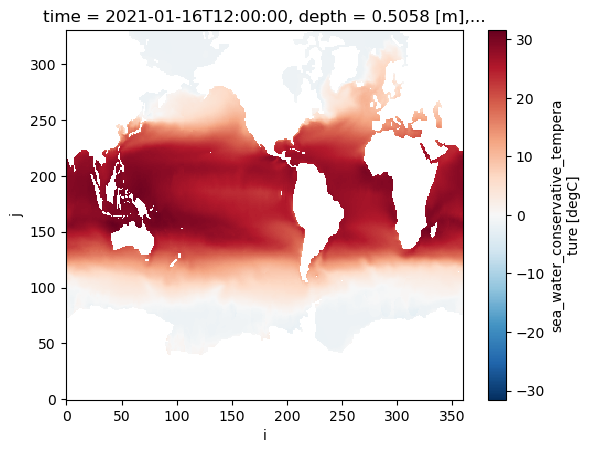

In [ ]:
# Reconstruct the field by adding the monthly climatology back to the regridded anomalies:
da_regrid = da.fillna(0).where(grid_mask) + ds_clim["thetao_con"]

da_regrid[0, 0, :, :].plot()